<a href="https://colab.research.google.com/github/Cecilia-Yuen/reviving-libguides-with-lean-ux/blob/main/libguide_ux_testing_tool_PUBLIC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Library Usability Study: User Experience Analysis

This notebook contains the production-ready code for conducting and analyzing a library usability study. It leverages Gradio for an interactive user interface and pandas/matplotlib/seaborn for data analysis and visualization.

## Prompting Strategy: CLEAR Framework
This project was developed using the **CLEAR Framework** for effective prompting, ensuring that instructions were:
- **C**oncise: Focused and to the point.
- **L**ogical: Steps followed a natural, coherent order.
- **E**xplicit: Clearly stated requirements and constraints.
- **A**daptive: Allowed for iterative refinement based on feedback.
- **R**eflective: Encouraged evaluation and improvement of outputs.

## Data Privacy Note
All user data collected through the Gradio interface is handled with strict adherence to privacy protocols. Raw user inputs and participant IDs are processed and stored locally (or via user-specified external services) with appropriate sanitization to protect user confidentiality.

In [4]:
import gradio as gr
import pandas as pd
import datetime
import os

# Basic clean CSS for the Gradio app
custom_css = """
.container { max-width: 900px; margin: auto; padding-top: 20px; }
.task-box { border: 1px solid #d1d1d1; padding: 25px; border-radius: 8px; background-color: #ffffff; box-shadow: 0 2px 4px rgba(0,0,0,0.05); margin-bottom: 20px; }
.header-text { text-align: center; color: #00274c; font-family: 'Helvetica', sans-serif; }
.progress-text { text-align: center; color: #2e7d32; font-size: 18px; font-weight: bold; margin-bottom: 15px; }
.submit-btn { background-color: #00274c !important; color: white !important; font-weight: bold; }
.reward-box { border: 2px solid #e6a817; padding: 30px; border-radius: 10px; background-color: #fffdf5; margin-bottom: 30px; }
footer {display: none !important;}
"""

FILE_NAME = "usability_study_results.csv"

# Initialize test_data with persistence logic
# If the CSV file exists, load it; otherwise, start with an empty list.
if os.path.exists(FILE_NAME):
    try:
        df_loaded = pd.read_csv(FILE_NAME, dtype=str)
        if 'Difficulty_Score' in df_loaded.columns:
            df_loaded['Difficulty_Score'] = pd.to_numeric(df_loaded['Difficulty_Score'], errors='coerce')
        test_data = df_loaded.to_dict('records')
        print(f"[Backend] Loaded {len(test_data)} records from {FILE_NAME}.")
    except Exception as e:
        print(f"[Backend] Error loading {FILE_NAME}: {e}. Initializing empty test_data.")
        test_data = []
else:
    test_data = []
    print(f"[Backend] {FILE_NAME} not found. Initializing empty test_data.")

def save_report(hksyu_email, task_name, user_answer, status, difficulty, feedback, comp_tasks):
    if not hksyu_email:
        return "⚠️ Session expired or email missing. Please refresh the page.", comp_tasks, "", gr.update()

    # Update completed tasks tracker
    if comp_tasks is None:
        comp_tasks = []
    if task_name not in comp_tasks and task_name.startswith("Task"): # Only count 'Task X' as completed
        comp_tasks.append(task_name)

    # Hidden correctness check for Tasks
    is_correct = None
    ans_lower = str(user_answer).strip().lower()

    if task_name == "Task 1":
        is_correct = ("evidence" in ans_lower or "argument" in ans_lower)
    elif task_name == "Task 2":
        is_correct = ("aybo" in ans_lower)
    elif task_name == "Task 3":
        is_correct = ("instructor" in ans_lower)
    elif task_name == "Task 4":
        is_correct = ("photograph" in ans_lower)
    elif task_name == "Task 5":
        is_correct = ("notes" in ans_lower)
    elif task_name == "Task 6":
        is_correct = ("endnote" in ans_lower)
    elif task_name == "Task 7":
        is_correct = ("tag" in ans_lower)

    # Generate Timestamp in Hong Kong Time (UTC+8)
    hkt_timezone = datetime.timezone(datetime.timedelta(hours=8))
    timestamp_hkt = datetime.datetime.now(hkt_timezone).strftime("%Y-%m-%d %H:%M")

    data = {
        "Timestamp": timestamp_hkt,
        "HKSYU_Email": hksyu_email,
        "Task_Name": task_name,
        "User_Answer": user_answer,
        "Is_Correct_Backend": is_correct,
        "Status": status,
        "Difficulty_Score": difficulty,
        "Feedback": feedback
    }
    test_data.append(data)

    # Save test_data to CSV immediately after appending (local persistence)
    df_to_save = pd.DataFrame(test_data)
    df_to_save.to_csv(FILE_NAME, index=False)
    print(f"[Backend] Data recorded for task: {task_name}")

    # Generate progress message (only counting actual Task 1-7)
    task_count = len([t for t in comp_tasks if t.startswith("Task") and t != "Future Participation"])
    progress_msg = f"✅ **Progress:** {task_count} / 7 Tasks Completed."

    # Show rewards section if all 7 tasks are completed
    show_rewards = gr.update(visible=False)
    if task_count >= 7:
        progress_msg += " 🎉 **You have completed all tasks! Please claim your rewards below!**"
        show_rewards = gr.update(visible=True)

    return f"Success: Data for '{task_name}' has been recorded.", comp_tasks, progress_msg, show_rewards

# 2. UI Layout
with gr.Blocks() as demo:
    gr.Markdown("# Academic Writing and Citation Practices Guide Usability Study", elem_classes="header-text")

    # Hidden states to manage user session and completed tasks
    user_email_state = gr.State("")
    completed_tasks_state = gr.State([])

    # Welcome Screen (Login)
    with gr.Column(visible=True) as welcome_screen:
        with gr.Column(elem_classes="task-box"):
            gr.Markdown("### Welcome! To begin the usability study, please enter your HKSYU email.")
            email_input = gr.Textbox(label="HKSYU Email (Required)", placeholder="e.g., username@hksyu.edu.hk")
            start_btn = gr.Button("Start Tasks", elem_classes="submit-btn")
            email_warning = gr.Markdown()

    # Study Screen (Tasks and iframe)
    with gr.Column(visible=False) as study_screen:
        email_display = gr.Markdown() # Displays logged-in email
        progress_display = gr.Markdown("✅ **Progress:** 0 / 7 Tasks Completed.", elem_classes="progress-text") # Displays task progress

        # Prominent Rewards Section (Visible ONLY after all 7 tasks are completed)
        with gr.Column(visible=False, elem_classes="reward-box") as rewards_screen:
            gr.Markdown("""## 🎁 Rewards & Part 2 Studies\n\n### 🎉 Thank You!\nThank you for completing the tasks! If you are eligible, you will be notified by email about how to receive a **canvas bag**.\n\n### 🔮 Next Round of Research\nIf you would like to participate in the next round of the Online UX Research Meeting, please select **Yes** below. We will then send you the status and details of your successful selection for the meeting.""")
            ux_res = gr.Radio(["Yes", "No"], label="Participate in the next round?")
            ux_note = gr.Textbox(label="Any final feedback? (Optional)", lines=3)
            btn_ux = gr.Button("Submit Selection", elem_classes="submit-btn")
            msg_ux = gr.Markdown()

        with gr.Row():
            # Left side: Iframe for the library guide
            with gr.Column(scale=3):
                gr.HTML('<iframe src="https://hksyu.libguides.com/academic_writing_citation" width="100%" height="1500" frameborder="0" allowfullscreen></iframe>')

            # Right side: Tabs for tasks
            with gr.Column(scale=1):
                gr.Markdown("### Please complete all Task 1 to Task 7 below.")
                with gr.Tabs(elem_classes="tabs"):
                    with gr.TabItem("Task 1"):
                        with gr.Column(elem_classes="task-box"):
                            gr.Markdown("""### 🔍 Instructions\nApart from being objective and well organised, what characterizes academic writing mainly?""")
                            t1_ans = gr.Textbox(label="Your Answer", placeholder="Type your answer here...")
                            t1_res = gr.Radio(["Completed Successfully", "Completed with Difficulty", "Failed / Gave Up"], label="Task Status")
                            t1_diff = gr.Slider(1, 5, step=1, label="Difficulty Rating")
                            t1_note = gr.Textbox(label="User Observations / Frustrations", lines=3)
                            btn1 = gr.Button("Submit Task 1", elem_classes="submit-btn")
                            msg1 = gr.Markdown()

                    with gr.TabItem("Task 2"):
                        with gr.Column(elem_classes="task-box"):
                            gr.Markdown("""### 🔍 Instructions\nFind the AI platform name for teaching different genres of writing, developed by the Language Centre.""")
                            t2_ans = gr.Textbox(label="Your Answer", placeholder="Type your answer here...")
                            t2_res = gr.Radio(["Completed Successfully", "Completed with Difficulty", "Failed / Gave Up"], label="Task Status")
                            t2_diff = gr.Slider(1, 5, step=1, label="Difficulty Rating")
                            t2_note = gr.Textbox(label="User Observations / Frustrations", lines=3)
                            btn2 = gr.Button("Submit Task 2", elem_classes="submit-btn")
                            msg2 = gr.Markdown()

                    with gr.TabItem("Task 3"):
                        with gr.Column(elem_classes="task-box"):
                            gr.Markdown("""### 🔍 Instructions\nIf the student does not know what citations to use for a specific assignment, who should they ask?""")
                            t3_ans = gr.Textbox(label="Your Answer", placeholder="Type your answer here...")
                            t3_res = gr.Radio(["Completed Successfully", "Completed with Difficulty", "Failed / Gave Up"], label="Task Status")
                            t3_diff = gr.Slider(1, 5, step=1, label="Difficulty Rating")
                            t3_note = gr.Textbox(label="User Observations / Frustrations", lines=3)
                            btn3 = gr.Button("Submit Task 3", elem_classes="submit-btn")
                            msg3 = gr.Markdown()

                    with gr.TabItem("Task 4"):
                        with gr.Column(elem_classes="task-box"):
                            gr.Markdown("""### 🔍 Instructions\nWhen conducting a sociological analysis of social media for an assignment, a student may need to cite a post as a primary source. Please fill in the template below in APA 7th style:\n\nZeitz MOCAA [@zeitzmocaa]. (2018, November 26). *Grade 6 learners*<br>&nbsp;&nbsp;&nbsp;&nbsp;*from Paskfields Primary School in Hanover Park visited the museum*<br>&nbsp;&nbsp;&nbsp;&nbsp;*for a tour and workshop hosted by* <mark>[Fill in the blank]</mark>. Instagram.<br>&nbsp;&nbsp;&nbsp;&nbsp;http://www.instagram.com/p/BqpHpjFBs3b/""")
                            t4_ans = gr.Textbox(label="Your Answer (Fill in the blank)", placeholder="Type the missing text here...")
                            t4_res = gr.Radio(["Completed Successfully", "Completed with Difficulty", "Failed / Gave Up"], label="Task Status")
                            t4_diff = gr.Slider(1, 5, step=1, label="Difficulty Rating")
                            t4_note = gr.Textbox(label="User Observations / Frustrations", lines=3)
                            btn4 = gr.Button("Submit Task 4", elem_classes="submit-btn")
                            msg4 = gr.Markdown()

                    with gr.TabItem("Task 5"):
                        with gr.Column(elem_classes="task-box"):
                            gr.Markdown("""### 🔍 Instructions\nApart from the Author–Date system, the Chicago Manual of Style uses the <mark>Fill in the blank</mark> and Bibliography system.""")
                            t5_ans = gr.Textbox(label="Your Answer (Fill in the blank)", placeholder="Type your answer here...")
                            t5_res = gr.Radio(["Completed Successfully", "Completed with Difficulty", "Failed / Gave Up"], label="Task Status")
                            t5_diff = gr.Slider(1, 5, step=1, label="Difficulty Rating")
                            t5_note = gr.Textbox(label="User Observations / Frustrations", lines=3)
                            btn5 = gr.Button("Submit Task 5", elem_classes="submit-btn")
                            msg5 = gr.Markdown()

                    with gr.TabItem("Task 6"):
                        with gr.Column(elem_classes="task-box"):
                            gr.Markdown("""### 🔍 Instructions\nWhich citation management tools have been subscribed to by the Library?""")
                            t6_ans = gr.Textbox(label="Your Answer", placeholder="Type your answer here...")
                            t6_res = gr.Radio(["Completed Successfully", "Completed with Difficulty", "Failed / Gave Up"], label="Task Status")
                            t6_diff = gr.Slider(1, 5, step=1, label="Difficulty Rating")
                            t6_note = gr.Textbox(label="User Observations / Frustrations", lines=3)
                            btn6 = gr.Button("Submit Task 6", elem_classes="submit-btn")
                            msg6 = gr.Markdown()

                    with gr.TabItem("Task 7"):
                        with gr.Column(elem_classes="task-box"):
                            gr.Markdown("""### 🔍 Instructions\nAfter adding literature to Zotero, you can organize it by assigning Collections, adding notes for supplementary information, and adding <mark>Fill in the blank</mark> to each item for easier organization.""")
                            t7_ans = gr.Textbox(label="Your Answer (Fill in the blank)", placeholder="Type your answer here...")
                            t7_res = gr.Radio(["Completed Successfully", "Completed with Difficulty", "Failed / Gave Up"], label="Task Status")
                            t7_diff = gr.Slider(1, 5, step=1, label="Difficulty Rating")
                            t7_note = gr.Textbox(label="User Observations / Frustrations", lines=3)
                            btn7 = gr.Button("Submit Task 7", elem_classes="submit-btn")
                            msg7 = gr.Markdown()

        # Connect Task Submit Events to update progress and potentially show rewards
        btn1.click(save_report, [user_email_state, gr.State("Task 1"), t1_ans, t1_res, t1_diff, t1_note, completed_tasks_state], [msg1, completed_tasks_state, progress_display, rewards_screen])
        btn2.click(save_report, [user_email_state, gr.State("Task 2"), t2_ans, t2_res, t2_diff, t2_note, completed_tasks_state], [msg2, completed_tasks_state, progress_display, rewards_screen])
        btn3.click(save_report, [user_email_state, gr.State("Task 3"), t3_ans, t3_res, t3_diff, t3_note, completed_tasks_state], [msg3, completed_tasks_state, progress_display, rewards_screen])
        btn4.click(save_report, [user_email_state, gr.State("Task 4"), t4_ans, t4_res, t4_diff, t4_note, completed_tasks_state], [msg4, completed_tasks_state, progress_display, rewards_screen])
        btn5.click(save_report, [user_email_state, gr.State("Task 5"), t5_ans, t5_res, t5_diff, t5_note, completed_tasks_state], [msg5, completed_tasks_state, progress_display, rewards_screen])
        btn6.click(save_report, [user_email_state, gr.State("Task 6"), t6_ans, t6_res, t6_diff, t6_note, completed_tasks_state], [msg6, completed_tasks_state, progress_display, rewards_screen])
        btn7.click(save_report, [user_email_state, gr.State("Task 7"), t7_ans, t7_res, t7_diff, t7_note, completed_tasks_state], [msg7, completed_tasks_state, progress_display, rewards_screen])

        # Event for Reward Section Submit
        btn_ux.click(save_report, [user_email_state, gr.State("Future Participation"), gr.State(""), ux_res, gr.State(0), ux_note, completed_tasks_state], [msg_ux, completed_tasks_state, progress_display, rewards_screen])

    # Function to handle login transition
    def start_study(email):
        if not email or "@" not in email:
            return gr.update(visible=True), gr.update(visible=False), "⚠️ Please enter a valid email address.", gr.update(), ""
        return gr.update(visible=False), gr.update(visible=True), "", f"✅ **Logged in as:** {email}", email

    start_btn.click(start_study, inputs=[email_input], outputs=[welcome_screen, study_screen, email_warning, email_display, user_email_state])

    # Researcher Portal (for viewing collected data)
    with gr.Accordion("📊 Researcher Dashboard (Internal Use Only)", open=False):
        gr.Markdown("🔒 Enter password to unlock the data table.")
        admin_pwd = gr.Textbox(label="Admin Password", type="password")

        with gr.Column(visible=False) as hidden_dashboard:
            view_btn = gr.Button("Refresh Data Table")
            data_table = gr.DataFrame(label="Collected Usability Data")

            def show_data():
                # Ensure test_data reflects the latest state, though it should be global
                if os.path.exists(FILE_NAME):
                    try:
                        df_latest = pd.read_csv(FILE_NAME)
                        return df_latest
                    except Exception:
                        return pd.DataFrame() # Return empty if file corrupt
                return pd.DataFrame(test_data)

            view_btn.click(show_data, outputs=data_table)

            export_btn = gr.Button("Prepare CSV for Download")
            download_file = gr.File(label="Download File")

            def export_csv_file():
                # This function will be called on the backend when the user clicks 'Export'
                # The CSV is already kept up-to-date by save_report, so just return the path
                return FILE_NAME

            export_btn.click(export_csv_file, outputs=download_file)

        def check_pwd(pwd):
            # Hardcoded password for demonstration purposes
            if pwd == "researcher123":
                return gr.Column(visible=True)
            return gr.Column(visible=False)

        admin_pwd.change(check_pwd, inputs=admin_pwd, outputs=hidden_dashboard)
        admin_pwd.submit(check_pwd, inputs=admin_pwd, outputs=hidden_dashboard)

# Launch the Gradio app
demo.launch(share=True, debug=False, css=custom_css) # Use share=True for Colab public link

# ==============================================================================
# (Optional) Deployment to Hugging Face Spaces
# ==============================================================================
# To automatically upload and host this interface on Hugging Face Spaces:
#
# from huggingface_hub import HfApi
# api = HfApi()
# api.upload_folder(
#     folder_path=".",
#     repo_id="your-username/your-space-name",
#     repo_type="space",
#     token="YOUR_HUGGINGFACE_TOKEN"
# )

[Backend] usability_study_results.csv not found. Initializing empty test_data.
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5702d99cbd3e51e98e.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


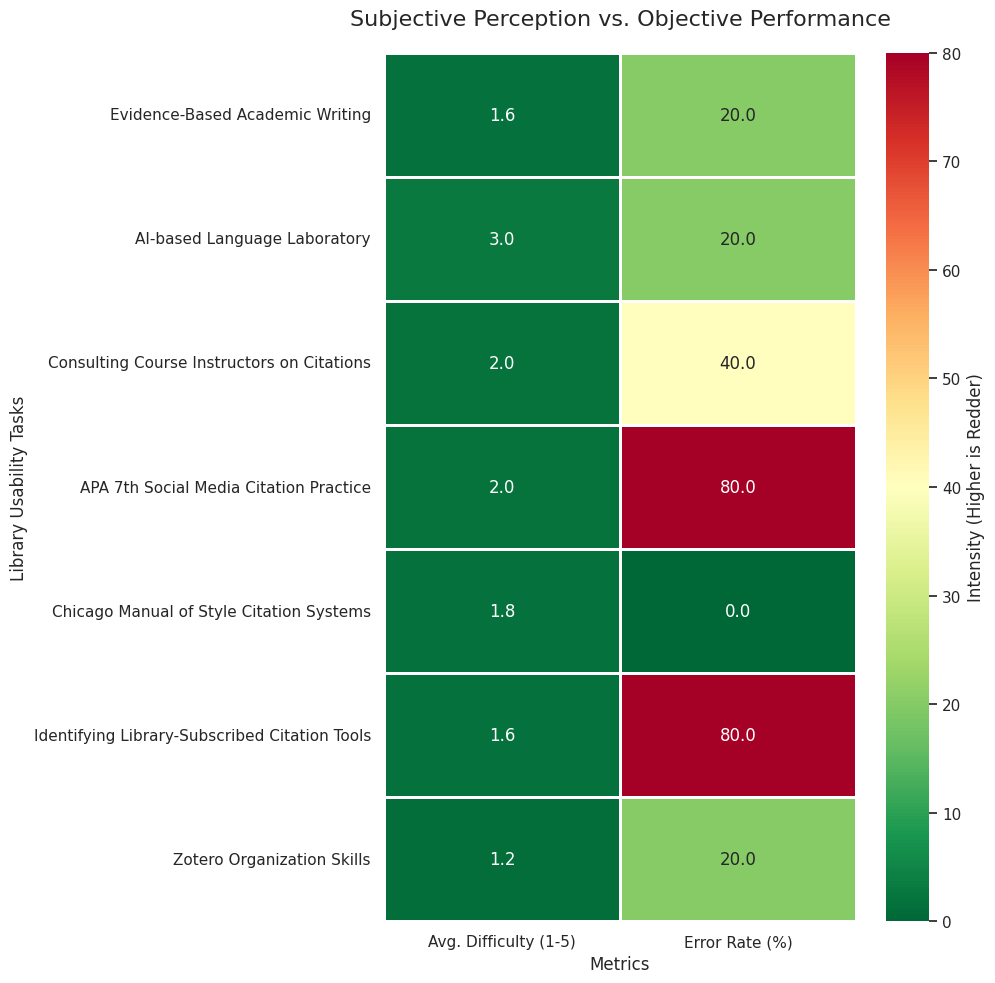

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data
file_path = '/content/Summary_for visualization_clean version_14.08.2026.xlsx'
df = pd.read_excel(file_path)

# 2. Clean Data
df['Difficulty_Score'] = pd.to_numeric(df['Difficulty_Score'], errors='coerce')
# Filter for Task entries and exclude Future Participation
df_filtered = df[df['Task_Name'].str.startswith('Task ', na=False)].copy()
df_filtered = df_filtered[df_filtered['Task_Name'] != 'Future Participation']

# 3. Calculate Metrics
# Metric A: Average Difficulty
avg_diff = df_filtered.groupby('Task_Name')['Difficulty_Score'].mean()

# Metric B: Error Rate (%)
# We assume values other than 1.0 (True) in Is_Correct_Backend are errors
# Adjusting calculation to handle potential float/bool representations
df_filtered['Is_Wrong'] = df_filtered['Is_Correct_Backend'].apply(lambda x: 1 if x == 0 or x == 0.0 or str(x).lower() == 'false' else 0)
error_rate = df_filtered.groupby('Task_Name')['Is_Wrong'].mean() * 100

# 4. Combine and Professionalize Task Names
task_mapping = {
    'Task 1': 'Evidence-Based Academic Writing',
    'Task 2': 'AI-based Language Laboratory',
    'Task 3': 'Consulting Course Instructors on Citations',
    'Task 4': 'APA 7th Social Media Citation Practice',
    'Task 5': 'Chicago Manual of Style Citation Systems',
    'Task 6': 'Identifying Library-Subscribed Citation Tools',
    'Task 7': 'Zotero Organization Skills'
}

comparison_df = pd.DataFrame({
    'Avg. Difficulty (1-5)': avg_diff,
    'Error Rate (%)': error_rate
})

# Map professional names and reorder
comparison_df.index = comparison_df.index.map(task_mapping)
ordered_tasks = [task_mapping[f'Task {i}'] for i in range(1, 8) if f'Task {i}' in task_mapping]
comparison_df = comparison_df.reindex(ordered_tasks)

# 5. Plotting
plt.figure(figsize=(10, 10))
sns.set_theme(style='white')

# Using two separate heatmaps or one combined matrix with normalization would be complex for scale differences,
# but we will plot them together with clear annotations for contrast.
ax = sns.heatmap(comparison_df,
                 annot=True,
                 fmt='.1f',
                 cmap='RdYlGn_r',
                 linewidths=2,
                 cbar_kws={'label': 'Intensity (Higher is Redder)'})

plt.title('Subjective Perception vs. Objective Performance', fontsize=16, pad=20)
plt.xlabel('Metrics', fontsize=12)
plt.ylabel('Library Usability Tasks', fontsize=12)
plt.tight_layout()
plt.show()